### Rep Rate using previous evaluations

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_earth = 5.972e24     # kg
R_earth = 6371e3       # m
altitude = 500e3       # m
r_orbit = R_earth + altitude

# Orbital radius
r = R_earth + altitude

# Circular orbital velocity 𝑣 = √𝐺𝑀/r
v = np.sqrt(G * M_earth / r)

# Relative velocity on earth, or Ground speed, ve = v*R_earth/r
ve = v*R_earth/r

# STV Guidelines
GSD=6                  #Ground Sample Distance in m, comes from the ability to determine slopes on ground. 
Swath_width=1000       #in m

# Calculate Rep Rate
Number_spot=Swath_width/GSD
RepRate=Number_spot*(ve/GSD)
print(f" Rep Rate using the Spacecraft version: {RepRate*1e-3:.3f} kHz")

 Rep Rate using the Spacecraft version: 196.172 kHz


### Text in IEEE paper reads: In each sweep period (222µs), there will be 256 λ-clock ticks correspond to the designed 256 wavelengths.
222µs ~ 4.5 kHz

We calculate the reprate in two ways: 
1. one by calculationg it through airplace velocity and
2. through the sweep period

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
Separation= 0.203      # m, Along-track separation of footprints          
va = 115               # m/s, Airplane Speed 
WaveNum = 256          # Number of wavelengths per sweep
sweep_per_cycle = 8    # Sweeps per Full Cycle (256 Wavelengths)
Sweep_Rate = 4.5       # kHz, Laser Sweep Rate
Sweep_Period = 222e-6  # 222µs, Laser Sweep Period

# Calculate Rep Rate through Number of points along plane velocity
NumP = va/Separation
Reprate_air0 = NumP * WaveNum 

# Calculate Rep Rate through sweep rate (assuming that 8 sweeps are used for one complete cycle with 256 spots)
Reprate_air1 = Sweep_Rate * WaveNum/sweep_per_cycle

# Calculate Rep Rate through sweep rate (assuming that 8 sweeps are used for one complete cycle with 256 spots)
Reprate_air2 = WaveNum/sweep_per_cycle/Sweep_Period

# Print
print(f"Rep Rate using the Aircraft version 0: {Reprate_air0*1e-3:.3f} kHz")
print(f"Rep Rate using the Aircraft version 1: {Reprate_air1:.3f} kHz")
print(f"Rep Rate using the Aircraft version 2: {Reprate_air2*1e-3:.3f} kHz")

Rep Rate using the Aircraft version 0: 145.025 kHz
Rep Rate using the Aircraft version 1: 144.000 kHz
Rep Rate using the Aircraft version 2: 144.144 kHz


#### Consider the fact that all the 256 spots are scanned in 8 sweeps. So each sweep has 32 points imaged on a 2x8 pixel detector. 
#### Assuming it takes 222 µs to scan through the 32 points per scan, we calculate and ponder on some parameters below.

In [46]:
import numpy as np
import matplotlib.pyplot as plt

Sweep_Period = 222e-6  # 222µs, Laser Sweep Period

# Assuming each pixel recieves 4 spots before the scan moves to the next pixel
# Time it takes for the detector output to receive subsequent data from one pixel
Dwell_time_pix=Sweep_Period/4
FreqDwell_time_pix=1/Dwell_time_pix

print(f"Dwell time on one pixel: {Dwell_time_pix*1e6:.3f} µs")
print(f"Dwell time Frequency on one pixel:: {FreqDwell_time_pix*1e-3:.3f} kHz")

Dwell time on one pixel: 55.500 µs
Dwell time Frequency on one pixel:: 18.018 kHz


### Let's think of a case where we scan all the 256 wavelengths per sweep in one cycle instead of 8

In [47]:
import numpy as np
import matplotlib.pyplot as plt

Sweep_Period = 222e-6  # 222µs, Laser Sweep Period

# Assuming each pixel recieves 32 spots before the scan moves to the next pixel
# Time it takes for the detector output to receive subsequent data from one pixel
Dwell_time_pix1=Sweep_Period/32
FreqDwell_time_pix1=1/Dwell_time_pix1

print(f"Dwell time on one pixel: {Dwell_time_pix1*1e6:.3f} µs")
print(f"Dwell time Frequency on one pixel:: {FreqDwell_time_pix1*1e-3:.3f} kHz")

Dwell time on one pixel: 6.938 µs
Dwell time Frequency on one pixel:: 144.144 kHz


### The questions that needs to be answered and understood is how fast the detector output readings 

### Let us now think of the case for spacecraft version

In [48]:
import numpy as np
import matplotlib.pyplot as plt

ve=7062.32             #Ground speed if SC 
GSD=6                  #Ground Sample Distance in m, comes from the ability to determine slopes on ground. 
Swath_width=1000       #in m

# Calculate Rep Rate
Number_spot=Swath_width/GSD
RepRate=Number_spot*(ve/GSD)

# Since we are currently thinking of 3 sweeps across 56 detectors, our pixel dwell time and frequency can be evaluated as:
FreqDwell_time_pix64=RepRate/3
Dwell_time_pix64=1/FreqDwell_time_pix64

# Print results
print(f"Dwell time on one pixel: {Dwell_time_pix64*1e6:.3f} µs")
print(f"Dwell time Frequency on one pixel:: {FreqDwell_time_pix64*1e-3:.3f} kHz")

Dwell time on one pixel: 15.292 µs
Dwell time Frequency on one pixel:: 65.392 kHz


### Let's think of a case where we scan all the 167/168 wavelengths per sweep in one cycle instead of 8

In [49]:
import numpy as np
import matplotlib.pyplot as plt

ve=7062.32             #Ground speed if SC 
GSD=6                  #Ground Sample Distance in m, comes from the ability to determine slopes on ground. 
Swath_width=1000       #in m

# Calculate Rep Rate
Number_spot=Swath_width/GSD
RepRate=Number_spot*(ve/GSD)

# Since we are currently thinking of 3 sweeps across 56 detectors, our pixel dwell time and frequency can be evaluated as:
FreqDwell_time_pix167=RepRate
Dwell_time_pix167=1/FreqDwell_time_pix167

# Print results
print(f"Dwell time on one pixel: {Dwell_time_pix167*1e6:.3f} µs")
print(f"Dwell time Frequency on one pixel:: {FreqDwell_time_pix167*1e-3:.3f} kHz")

Dwell time on one pixel: 5.097 µs
Dwell time Frequency on one pixel:: 196.176 kHz


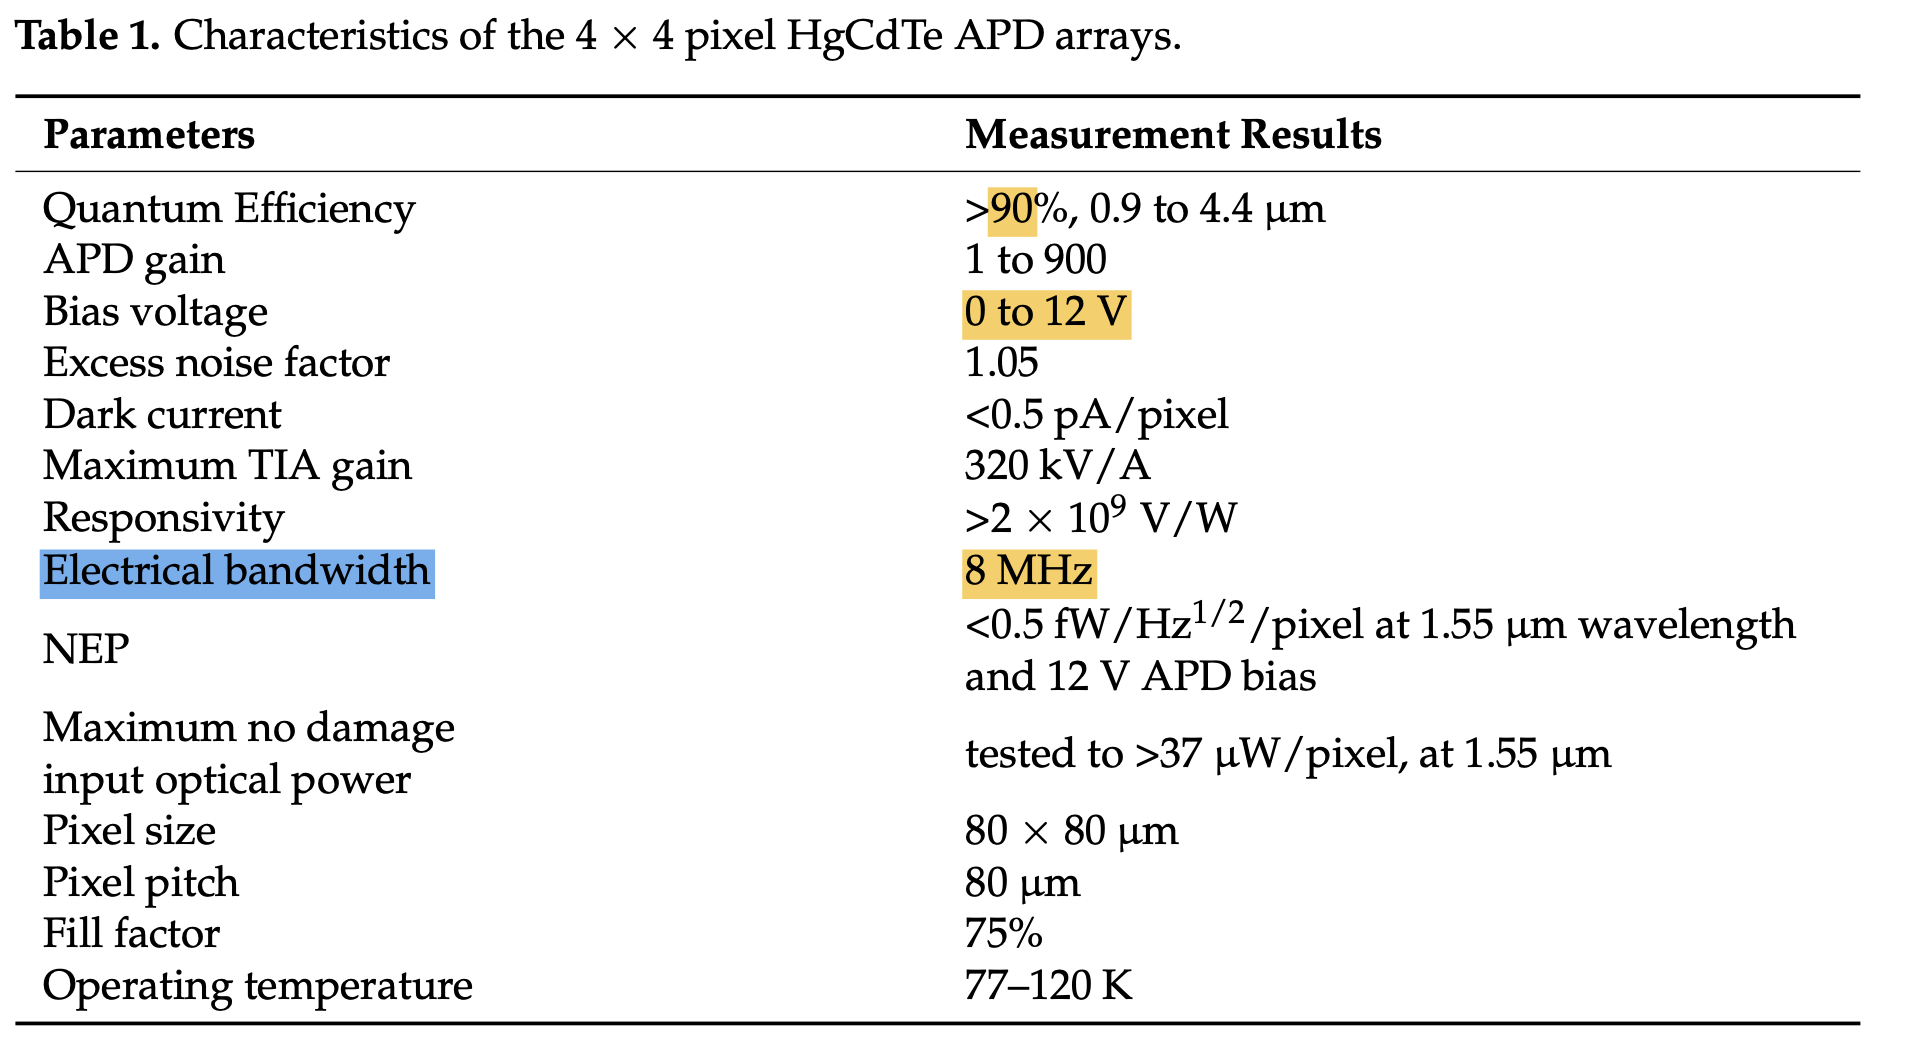

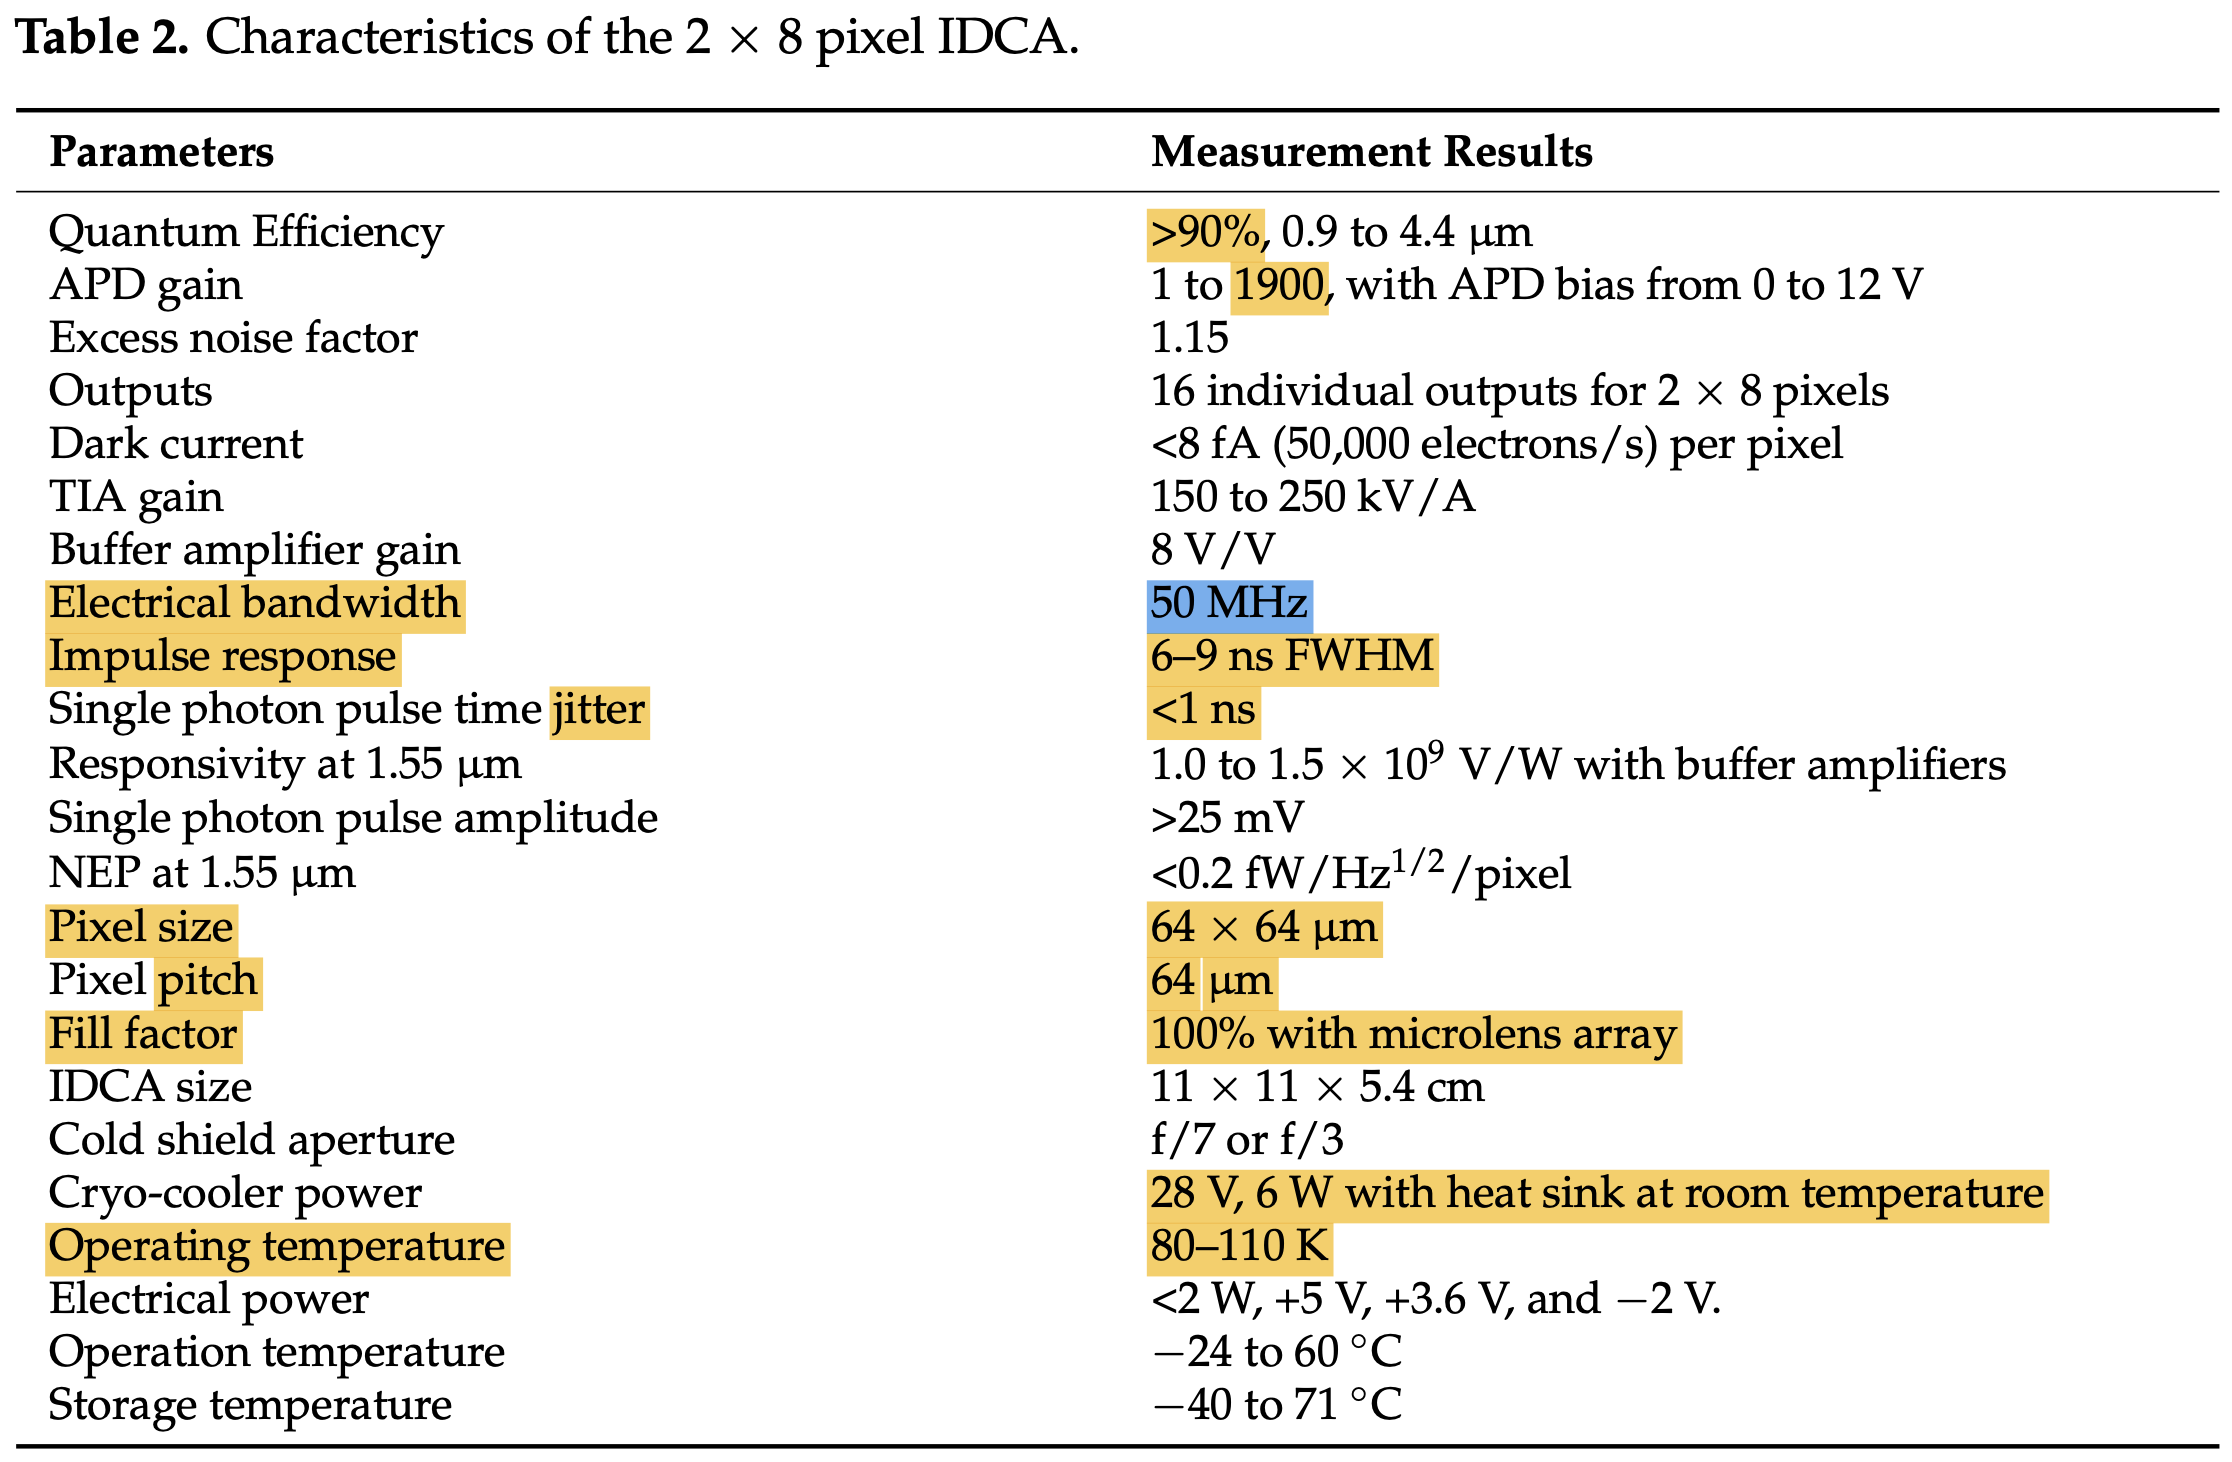

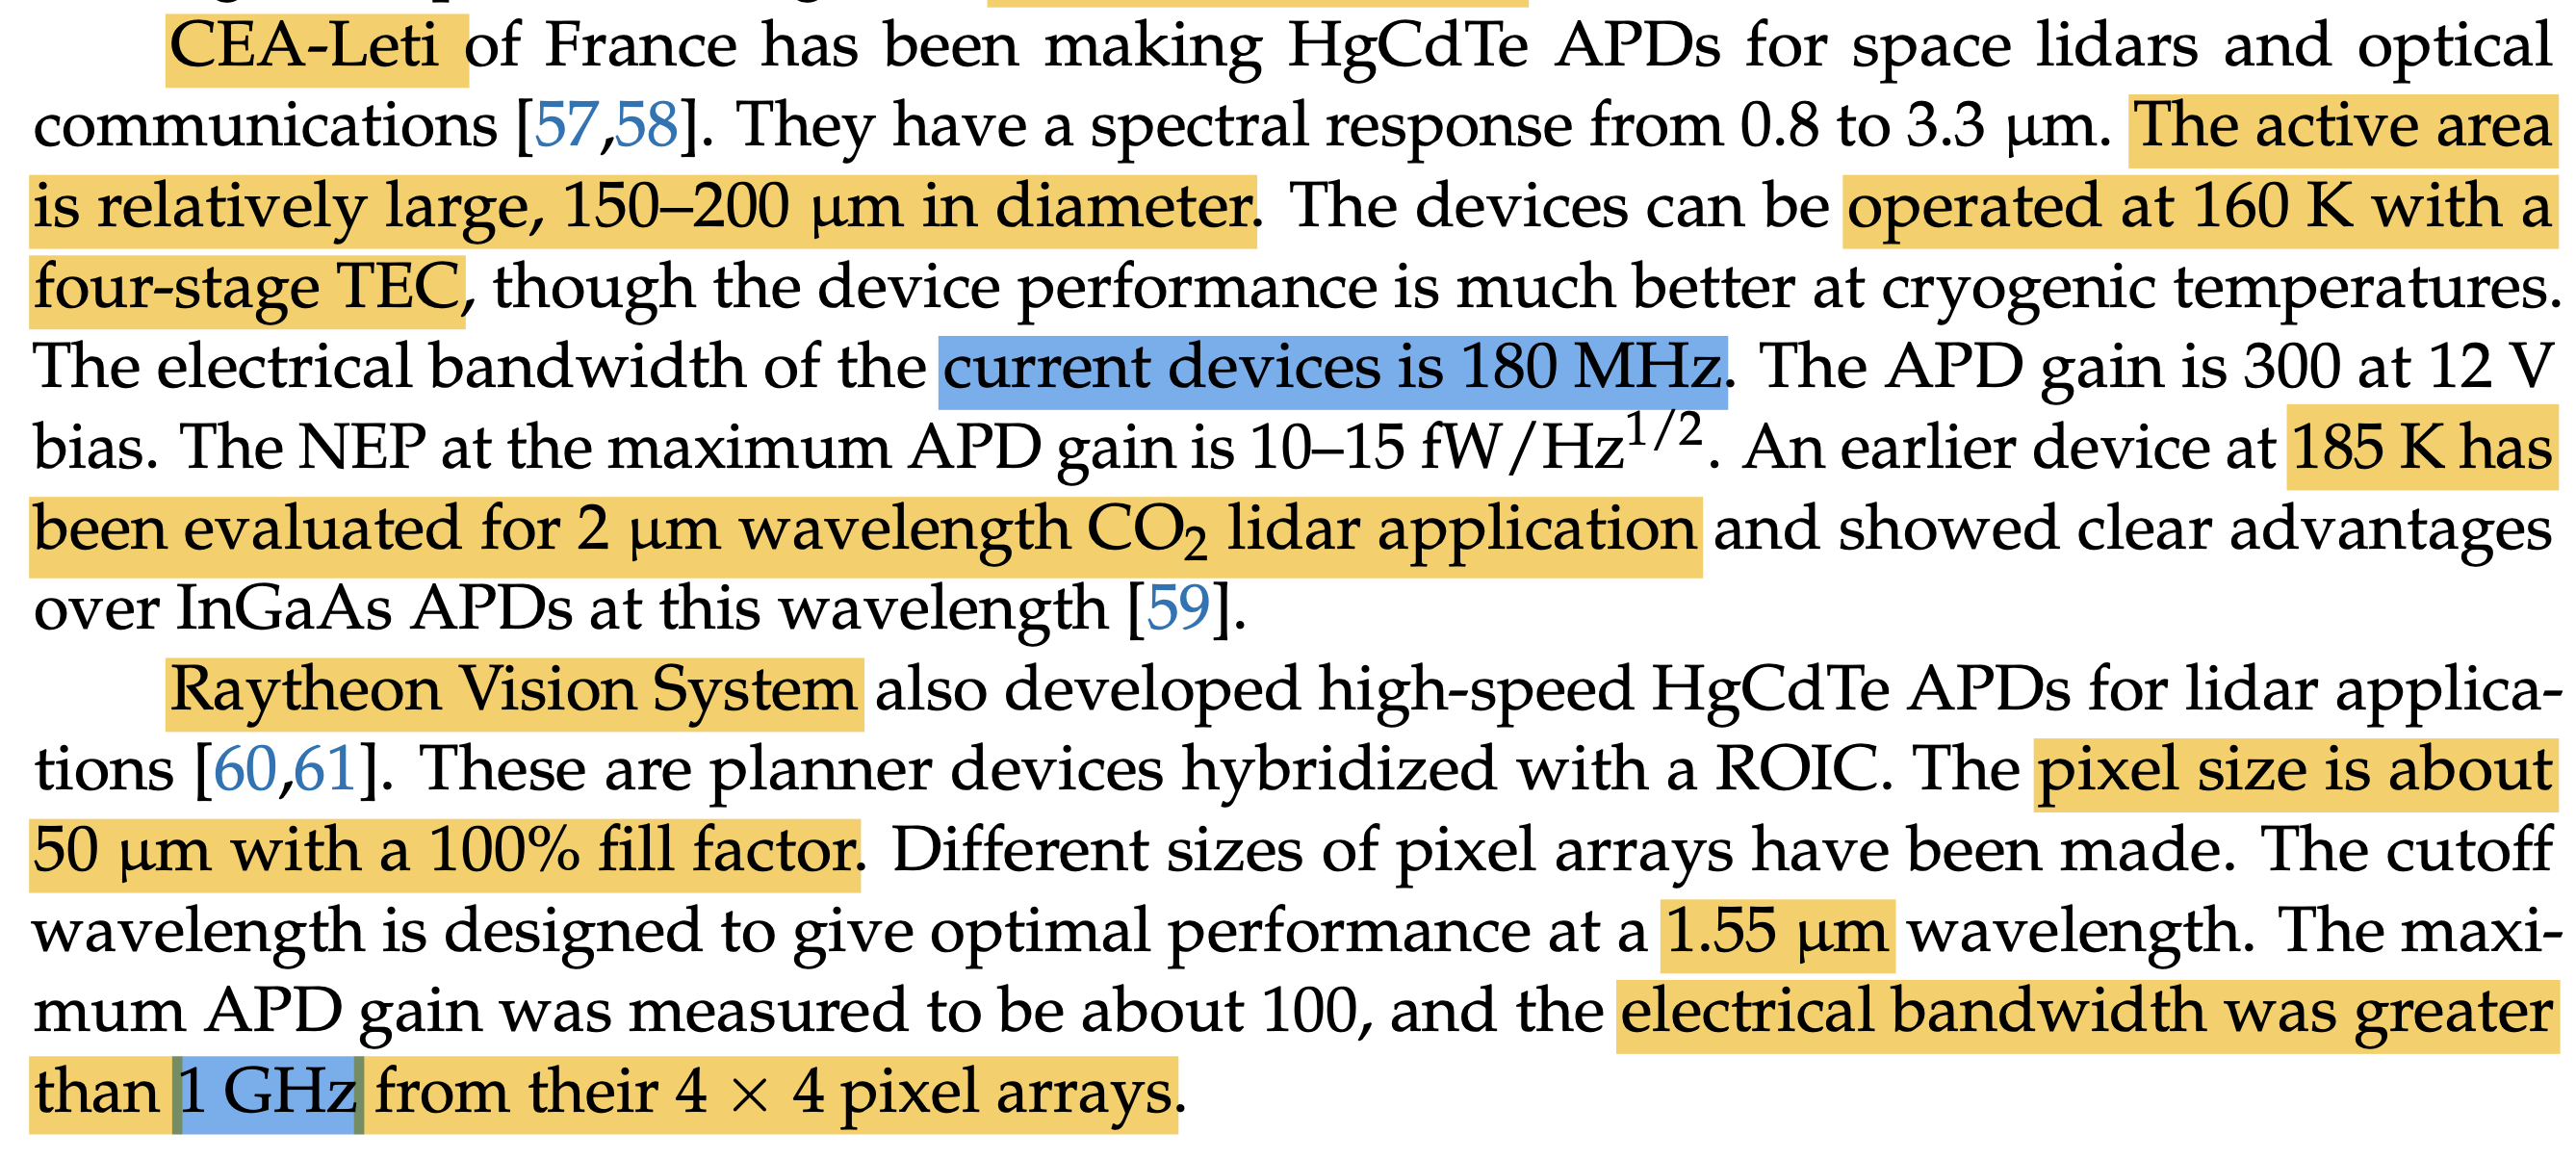

### Conclusion: We need a trade study on our options. There may be scope for simplification.